## Plots from Chinco Paper we could replicate

- plot that shows whether adding our lasso forecast to an ar(3) forecast increases oos r2
- our 2nd stage r2 are time invariant, we could get a market wide r2 by taking the mse of each stocks day ahead prediction and then aggregate

In [3]:
import pandas as pd
import numpy as np
import importlib
import cross_sectional_estimation_v1 as cse
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics.pairwise import cosine_similarity
from plot_style import apply
apply()
importlib.reload(cse)

<module 'cross_sectional_estimation_v1' from 'c:\\Users\\jonat\\Lasso_paper\\Empirical\\estimation\\cross_sectional_estimation_v1.py'>

In [15]:
import os
import h5py
import numpy as np
import pandas as pd

OUT_DIR = 'results_v1_1'

# ── Load tensor, coordinates, and performance metrics ────────────────────────
with h5py.File(os.path.join(OUT_DIR, 'betas.h5'), 'r') as f:
    betas   = f['betas'][:]               # (n_stocks, n_topics, n_dates) float32
    stocks  = f['stocks'][:].astype(str)
    topics  = f['topics'][:].astype(str)
    dates   = pd.to_datetime(f['dates'][:].astype(str))
    
    # Stage 1 information
    r2_in_mat = f['r2_in'][:]             # (n_stocks, n_dates)
    preds_mat = f['predictions'][:]       # (n_stocks, n_dates)
    targs_mat = f['targets'][:]           # (n_stocks, n_dates)
    
    # New Stage 2 and Intercept data
    intercepts_mat = f['lasso_intercepts'][:]   # (n_stocks, n_dates)
    s2_preds_mat   = f['stage2_predictions'][:] # (n_stocks, n_dates)
    s2_r2_in_mat   = f['stage2_r2_in'][:]       # (n_stocks, n_dates)

summary_df = pd.read_csv(os.path.join(OUT_DIR, 'summary.csv'), index_col=0)
summary_df.index = summary_df.index.astype(str)

# ── Derived quantities ───────────────────────────────────────────────────────
betas_nz = np.nan_to_num(betas, nan=0.0)
sel      = betas_nz != 0 

has_data     = np.isfinite(betas).any(axis=1)                      # (n_stocks, n_dates)
n_valid_days = has_data.sum(axis=1, keepdims=True).astype(float)

# Active topics metrics
active_per_day = sel.sum(axis=1).astype(float)
active_per_day[~has_data] = np.nan
mean_num_active = np.nanmean(active_per_day, axis=1)
summary_df['mean_num_active'] = pd.Series(mean_num_active, index=stocks)

# ── Performance Metrics Processing ───────────────────────────────────────────

# 1. Daily Average In-Sample R2 (Stage 1 vs Stage 2)
daily_avg_s1_r2_in = pd.Series(np.nanmean(r2_in_mat, axis=0), index=dates)
daily_avg_s2_r2_in = pd.Series(np.nanmean(s2_r2_in_mat, axis=0), index=dates)

# 2. Daily Cross-Sectional Out-of-Sample R2 (Stage 2)
# Market-wide explanatory power using Stage 2 predictions
s2_oos_errors_sq = (targs_mat - s2_preds_mat)**2
total_var_sq     = (targs_mat - np.nanmean(targs_mat, axis=0))**2

sum_sq_err_s2 = np.nansum(s2_oos_errors_sq, axis=0)
sum_sq_tot    = np.nansum(total_var_sq, axis=0)

# Calculate Stage 2 Daily OOS R2
daily_s2_r2_oos = pd.Series(1 - (sum_sq_err_s2 / sum_sq_tot), index=dates)

# Market-wide explanatory power using Stage 1 predictions
s1_oos_errors_sq = (targs_mat - preds_mat)**2

# total_var_sq is the same for both stages: (targs_mat - np.nanmean(targs_mat, axis=0))**2
total_var_sq = (targs_mat - np.nanmean(targs_mat, axis=0))**2

sum_sq_err_s1 = np.nansum(s1_oos_errors_sq, axis=0)
sum_sq_tot    = np.nansum(total_var_sq, axis=0)

# Calculate Stage 1 Daily OOS R2 (This fixes the NameError!)
daily_s1_r2_oos = pd.Series(1 - (sum_sq_err_s1 / sum_sq_tot), index=dates)

# ── Summary Output ───────────────────────────────────────────────────────────
print(f'Tensor    : {betas.shape}')
print(f'Stocks    : {len(stocks)}  ({(mean_num_active > 0).sum()} non-failed)')
print(f'Dates     : {len(dates)}  ({dates[0].date()} → {dates[-1].date()})')
print(f'Avg S1 IS R2 : {daily_avg_s1_r2_in.mean():.4f}')
print(f'Avg S2 IS R2 : {daily_avg_s2_r2_in.mean():.4f}')
print(f'Avg S1 OOS R2: {daily_s1_r2_oos.mean():.4f}')
print(f'Avg S2 OOS R2: {daily_s2_r2_oos.mean():.4f}')

# Performance Comparison DataFrame
performance_df = pd.DataFrame({
    'S1_IS_R2': daily_avg_s1_r2_in,
    'S2_IS_R2': daily_avg_s2_r2_in,
    'S1_Market_OOS_R2': daily_s1_r2_oos,
    'S2_Market_OOS_R2': daily_s2_r2_oos
})
performance_df.head()

Tensor    : (500, 180, 1869)
Stocks    : 500  (204 non-failed)
Dates     : 1869  (2010-02-02 → 2017-06-30)
Avg S1 IS R2 : 0.9493
Avg S2 IS R2 : -0.0557
Avg S1 OOS R2: -2.4291
Avg S2 OOS R2: -0.3362


C:\Users\jonat\AppData\Local\Temp\ipykernel_57292\2788165745.py:38: RuntimeWarning: Mean of empty slice
  mean_num_active = np.nanmean(active_per_day, axis=1)
C:\Users\jonat\AppData\Local\Temp\ipykernel_57292\2788165745.py:50: RuntimeWarning: Mean of empty slice
  total_var_sq     = (targs_mat - np.nanmean(targs_mat, axis=0))**2
C:\Users\jonat\AppData\Local\Temp\ipykernel_57292\2788165745.py:56: RuntimeWarning: invalid value encountered in divide
  daily_s2_r2_oos = pd.Series(1 - (sum_sq_err_s2 / sum_sq_tot), index=dates)
C:\Users\jonat\AppData\Local\Temp\ipykernel_57292\2788165745.py:62: RuntimeWarning: Mean of empty slice
  total_var_sq = (targs_mat - np.nanmean(targs_mat, axis=0))**2
C:\Users\jonat\AppData\Local\Temp\ipykernel_57292\2788165745.py:68: RuntimeWarning: invalid value encountered in divide
  daily_s1_r2_oos = pd.Series(1 - (sum_sq_err_s1 / sum_sq_tot), index=dates)


,S1_IS_R2,S2_IS_R2,S1_Market_OOS_R2,S2_Market_OOS_R2
2010-02-02,0.949818,-0.049604,-1.442867,1.000000
2010-02-03,0.944539,-0.059217,-2.687532,-0.239111
2010-02-04,0.917600,-0.074655,-3.311790,-0.768960
2010-02-05,0.916249,-0.076432,-0.946298,-0.015235
2010-02-08,0.897652,-0.102116,-0.578712,-0.307585


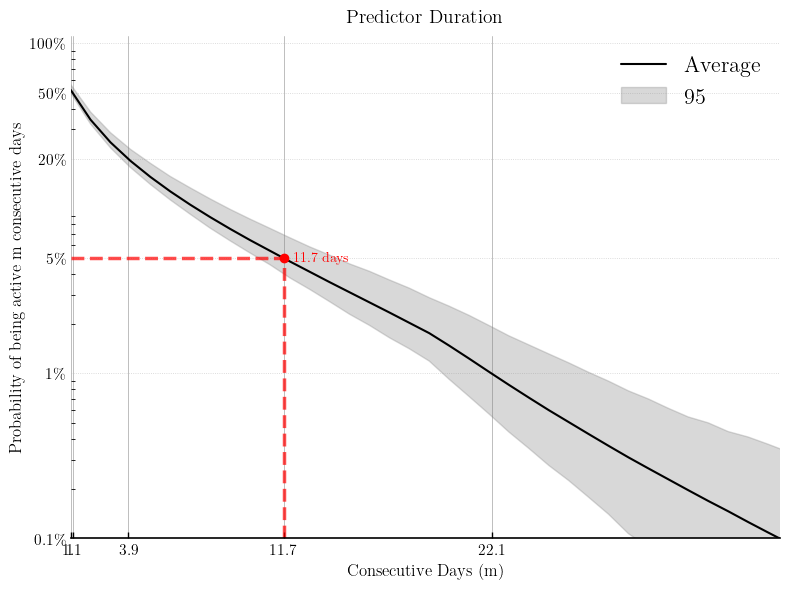

In [14]:
# this plot shows conditionally on being active, what is the probability for a predictor of being active for longer than m consecutive days (Fig 5 in Chinco paper)
# red line shows 5% quantile

    
# Replace NaNs with 0 and create a boolean mask of active predictors
betas_nz = np.nan_to_num(betas, nan=0.0)
is_used = betas_nz != 0

# 2. Compute run lengths (durations) per stock
durations_per_stock = []
for i in range(is_used.shape[0]):
    mask_2d = is_used[i] # Shape: (n_topics, n_dates)
    # Pad with False along the dates axis to catch bounds
    padded = np.pad(mask_2d, ((0,0), (1,1)), mode='constant', constant_values=False)
    diffs = np.diff(padded.astype(int), axis=1)
    
    # 1 indicates start of a sequence, -1 indicates the end
    starts = np.where(diffs == 1)
    ends = np.where(diffs == -1)
    durs = ends[1] - starts[1]
    
    if len(durs) > 0:
        durations_per_stock.append(durs)

if len(durations_per_stock) > 0:
    max_x = max([d.max() for d in durations_per_stock])
    x_grid = np.arange(1, max_x + 1)

    surv_probs = []
    for durs in durations_per_stock:
        # Calculate Complementary CDF: P(Duration > x)
        counts = np.bincount(durs, minlength=max_x+2)
        cdf = np.cumsum(counts) / len(durs)
        ccdf = 1.0 - cdf
        surv_probs.append(ccdf[x_grid])

    surv_probs = np.array(surv_probs)

    # 3. Calculate cross-sectional mean and 95% Confidence Interval
    mean_surv = surv_probs.mean(axis=0)
    lower_ci = np.percentile(surv_probs, 2.5, axis=0)
    upper_ci = np.percentile(surv_probs, 97.5, axis=0)

    # Filter out absolute 0 probabilities to safely plot on log scale
    valid_idx = mean_surv > 0
    x_plot = x_grid[valid_idx]
    mean_plot = mean_surv[valid_idx]
    lower_plot = lower_ci[valid_idx]
    upper_plot = upper_ci[valid_idx]

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(x_plot, mean_plot, color='black', linewidth=1.5, label='Average')
    ax.fill_between(x_plot, lower_plot, upper_plot, color='gray', alpha=0.3, label='95% CI')

    ax.set_yscale('log')
    
    # --- NEW: Cut the y-axis at 0.1% (0.001) ---
    ax.set_ylim(bottom=0.001, top=1.1)

    # --- NEW: Specific y-ticks matching the requested marks ---
    y_marks = [1, 0.5, 0.2, 0.05, 0.01, 0.001]
    ax.set_yticks(y_marks)
    ax.set_yticklabels([f"{y*100:g}\%" for y in y_marks])
    
    # Setting x-ticks to display durations associated with specific survival quantiles
    quantiles = [1, 0.5, 0.2, 0.05, 0.01]  # 50%, 20%, 5%, 1%
    x_ticks = [x_plot[0]]
    x_labels = [str(x_plot[0])]
    
    x_val_5pct = None
    
    # Determine the cutoff for 0.1% to limit the x-axis
    if mean_plot.min() <= 0.001 <= mean_plot.max():
        x_cutoff = np.interp(0.001, mean_plot[::-1], x_plot[::-1])
    else:
        x_cutoff = x_plot[-1]
    
    for q in quantiles:
        if mean_plot.min() <= q <= mean_plot.max():
            # x_plot and mean_plot are monotonic, reverse for numpy interpolation
            x_val = np.interp(q, mean_plot[::-1], x_plot[::-1])
            x_ticks.append(x_val)
            x_labels.append(f"{x_val:.1f}")
            
            if q == 0.05:
                x_val_5pct = x_val

    if x_ticks:
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_labels)

    # Clearly show the 5% mark
    if x_val_5pct is not None:
        ax.hlines(y=0.05, xmin=x_plot[0], xmax=x_val_5pct, color='red', linestyle='--', alpha=0.7)
        ax.vlines(x=x_val_5pct, ymin=0.001, ymax=0.05, color='red', linestyle='--', alpha=0.7)
        ax.scatter([x_val_5pct], [0.05], color='red', zorder=5)
        ax.text(x_val_5pct + 0.5, 0.05, f' {x_val_5pct:.1f} days', color='red', va='center', ha='left', fontweight='bold')

    # Limit the x-axis to the point where probability is 0.1%
    ax.set_xlim(left=x_plot[0], right=x_cutoff)

    ax.set_ylabel('Probability of being active m consecutive days', fontsize=12)
    ax.set_xlabel('Consecutive Days (m)', fontsize=12)
    ax.set_title('Predictor Duration', fontsize=14, pad=10)

    # Journal of Finance Style Formatting
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    ax.tick_params(axis='y', left=False) 
    ax.tick_params(axis='x', direction='in', length=4, width=1)
    
    # Add horizontal grid to map the specific percentages nicely
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
else:
    print("No non-zero predictors found.")

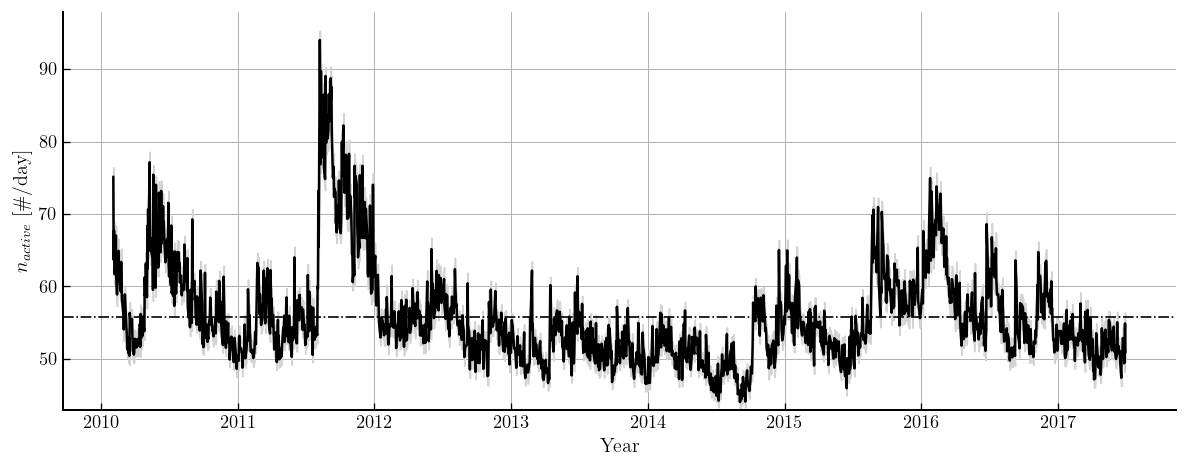

In [ ]:
# this is Fig 6 in Chinco paper

# 1. Calculation of the mean and 95% Confidence Interval
# We use axis=0 to average across all stocks for each specific date
mean_active = np.nanmean(active_per_day, axis=0)
std_active  = np.nanstd(active_per_day, axis=0)
n_stocks    = active_per_day.shape[0]

# Calculate 95% CI (1.96 * Standard Error)
ci_bound = 1.96 * (std_active / np.sqrt(n_stocks))

# 2. Plotting in the Chinco et al. Style
fig, ax = plt.subplots(figsize=(10, 4), dpi=120)

# The "Gray Bands" for the 95% Confidence Interval
ax.fill_between(dates, mean_active - ci_bound, mean_active + ci_bound, 
                color='#D3D3D3', label='95% Confidence Interval')

# The "Solid Line" for the daily average
ax.plot(dates, mean_active, color='black', linewidth=1.5, label='Daily Average')

# The "Dashed Line" for the full sample average (as seen in Chinco Fig 6)
full_sample_avg = np.nanmean(mean_active)
ax.axhline(full_sample_avg, color='black', linestyle='-.', linewidth=1)

# Styling to match the Journal of Finance
ax.set_ylabel(r'$n_{active}$ [\#/day]', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='in', length=4)
# Set the Y-axis to start at a meaningful round number
ax.set_ylim(bottom=np.floor(np.nanmin(mean_active) - 1))

plt.tight_layout()
plt.show()

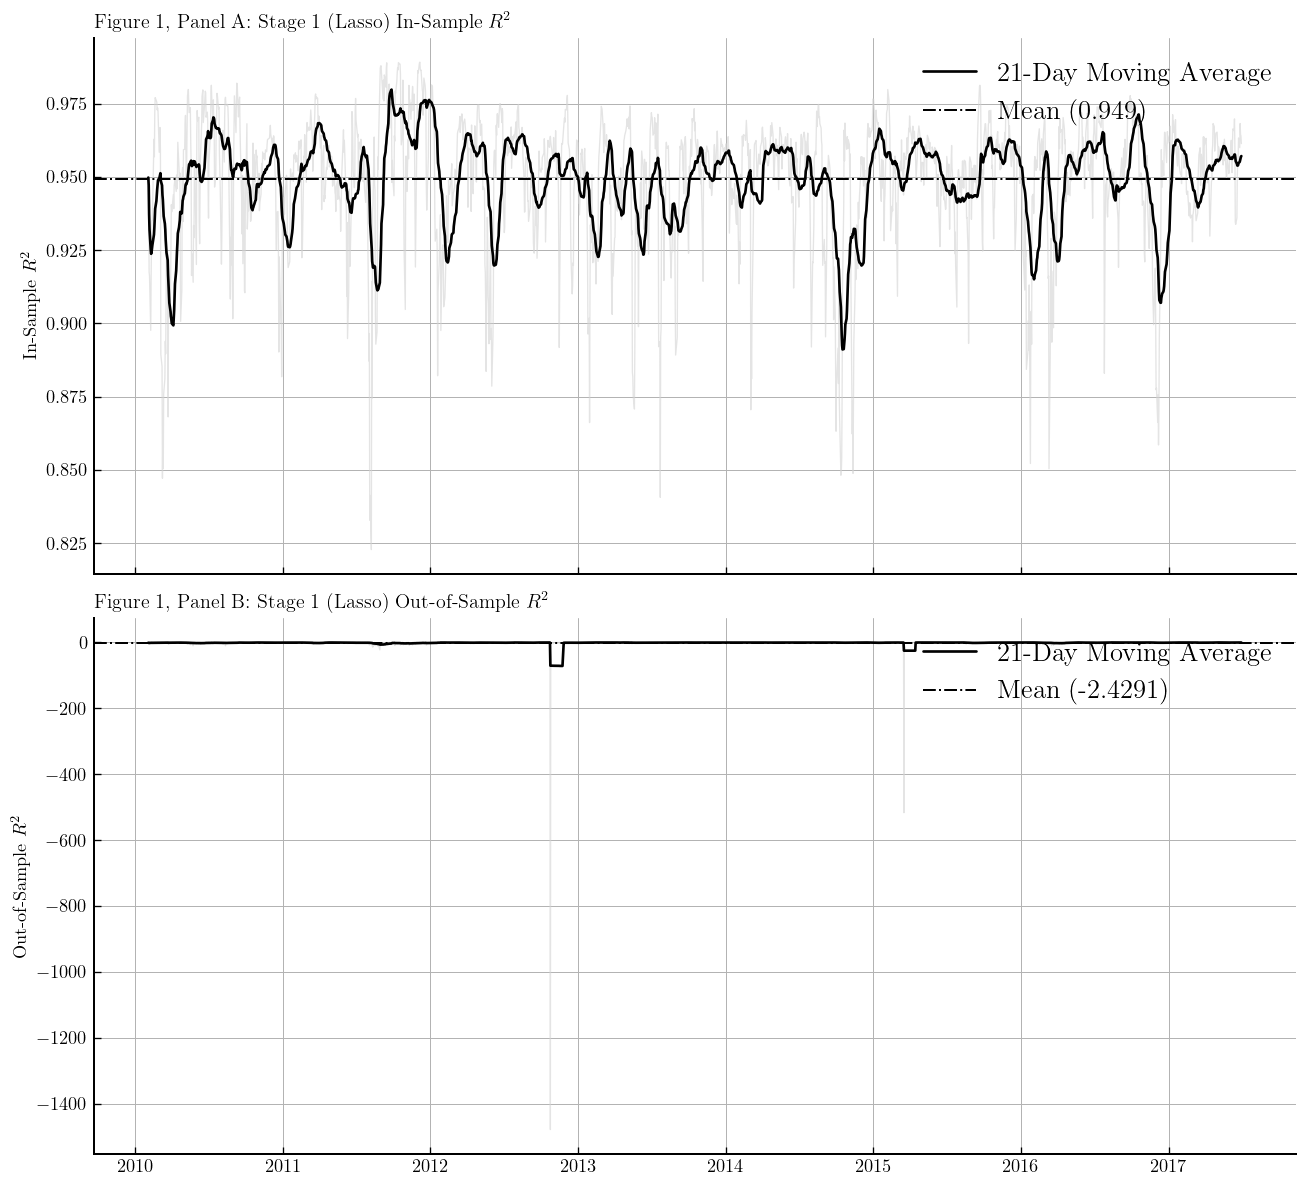

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Smoothing for Figure 1
ma_window = 21
s1_is_ma = daily_avg_s1_r2_in.rolling(window=ma_window, min_periods=1).mean()
s1_oos_ma = daily_s1_r2_oos.rolling(window=ma_window, min_periods=1).mean() # Original S1 OOS

# --- Figure 1: Stage 1 ---
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True, dpi=120)

# =============================================================================
# Panel A: Stage 1 In-Sample R-squared
# Calculation:
# 1. For each stock and each rolling window, the Lasso model's R² is computed 
#    during the training phase (fit to the window_size data).
# 2. These individual R² values are averaged across the cross-section of stocks 
#    for each specific date to create a daily market-wide IS R².
# =============================================================================
ax1.plot(daily_avg_s1_r2_in.index, daily_avg_s1_r2_in, color='#D3D3D3', lw=0.8, alpha=0.6)
ax1.plot(s1_is_ma.index, s1_is_ma, color='black', lw=1.6, label='21-Day Moving Average')
ax1.axhline(daily_avg_s1_r2_in.mean(), color='black', linestyle='-.', lw=1.2, label=f'Mean ({daily_avg_s1_r2_in.mean():.3f})')
ax1.set_title('Figure 1, Panel A: Stage 1 (Lasso) In-Sample $R^2$', loc='left', fontsize=12, fontweight='bold')
ax1.set_ylabel(r'In-Sample $R^2$', fontsize=11)

#  =============================================================================
# Panel B: Stage 1 Out-of-Sample R-squared
# Calculation:
# 1. We aggregate prediction errors (Target - Pred)^2 and total variation 
#    (Target - Cross_Sectional_Mean)^2 across all stocks for each day.
# 2. Daily OOS R² = 1 - (Sum of Squared Errors / Sum of Total Variance).
# 3. This measures how much of the market's return variation the Lasso signals 
#    can predict one step ahead.
# =============================================================================
ax2.plot(daily_s1_r2_oos.index, daily_s1_r2_oos, color='#D3D3D3', lw=0.8, alpha=0.6)
ax2.plot(s1_oos_ma.index, s1_oos_ma, color='black', lw=1.6, label='21-Day Moving Average')
ax2.axhline(daily_s1_r2_oos.mean(), color='black', linestyle='-.', lw=1.2, label=f'Mean ({daily_s1_r2_oos.mean():.4f})')
ax2.set_title('Figure 1, Panel B: Stage 1 (Lasso) Out-of-Sample $R^2$', loc='left', fontsize=12, fontweight='bold')
ax2.set_ylabel(r'Out-of-Sample $R^2$', fontsize=11)

# Formatting
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='in', length=4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

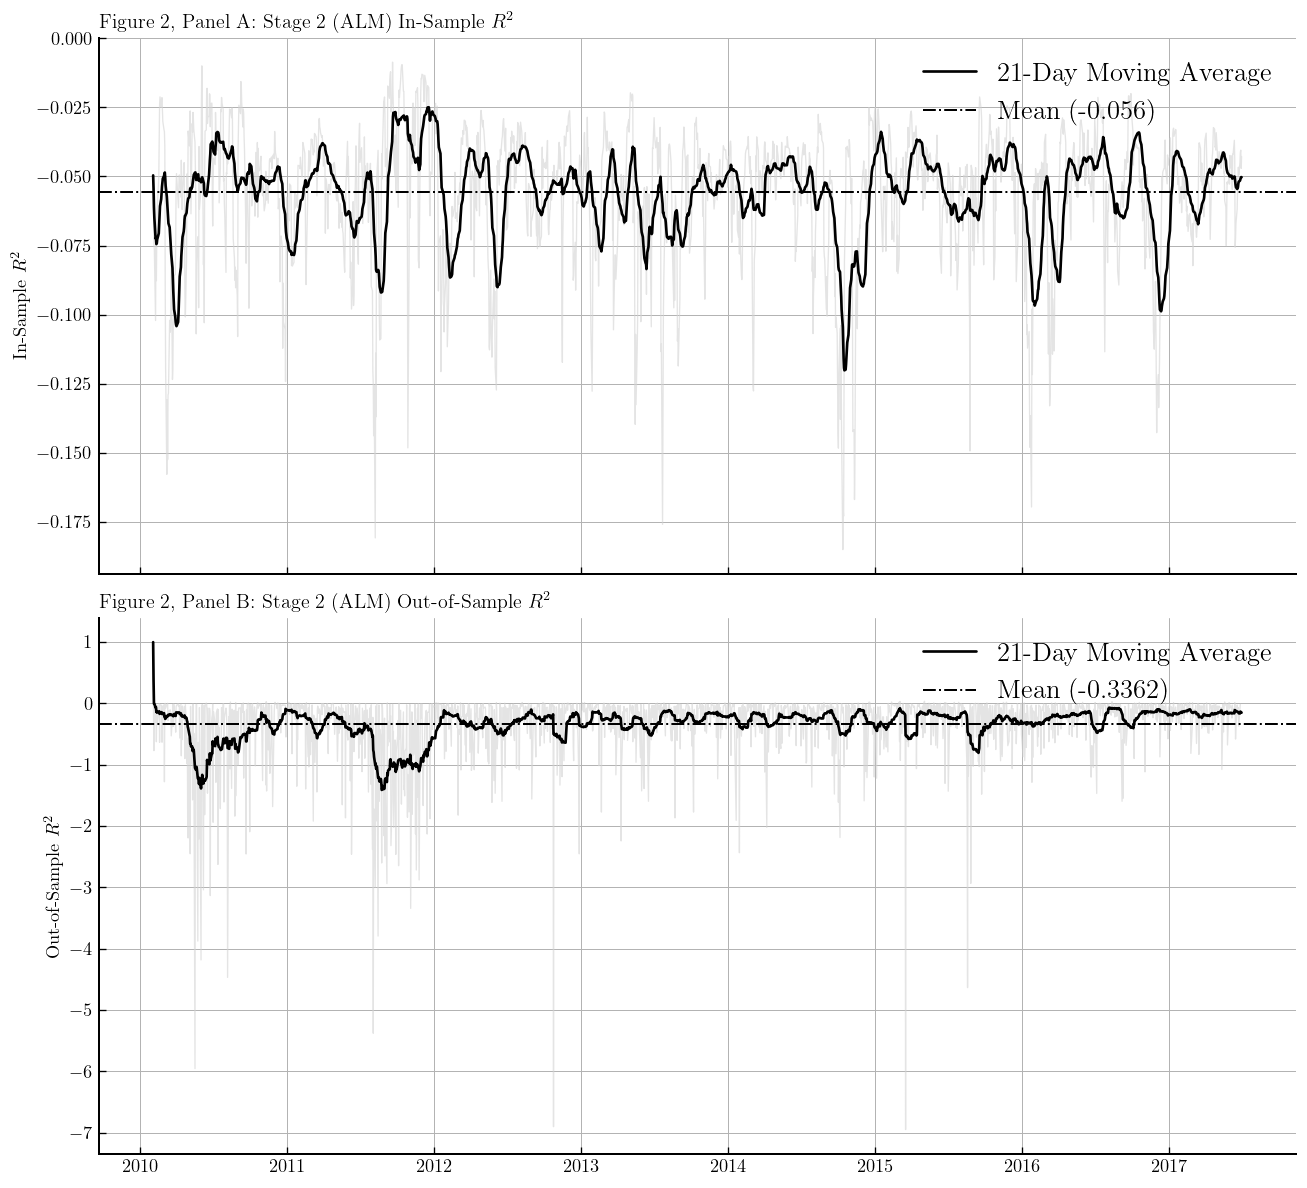

In [18]:
# ── 1. Preparation & Smoothing ───────────────────────────────────────────────
# Rolling average of Stage 2 In-Sample R2
s2_is_ma = daily_avg_s2_r2_in.rolling(window=ma_window, min_periods=1).mean()
# Rolling average of Stage 2 Out-of-Sample R2
s2_oos_ma = daily_s2_r2_oos.rolling(window=ma_window, min_periods=1).mean()

# --- Figure 2: Stage 2 Performance ---
fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True, dpi=120)

# =============================================================================
# Panel A: Stage 2 In-Sample R-squared
# Calculation:
# 1. We reconstruct Stage 1 in-sample predictions for each window and transform 
#    them using the global ALM formula: r_t = ln(1 - κe^pred_t) - ln(1 - κe^pred_t+1) + int.
# 2. We calculate the R² by comparing these estimated values to the actual 
#    returns within that same training window.
# 3. This measures how well the structural model fits the data within estimation windows across time.
# =============================================================================
ax1.plot(daily_avg_s2_r2_in.index, daily_avg_s2_r2_in, color='#D3D3D3', lw=0.8, alpha=0.6)
ax1.plot(s2_is_ma.index, s2_is_ma, color='black', lw=1.6, label='21-Day Moving Average')
ax1.axhline(daily_avg_s2_r2_in.mean(), color='black', linestyle='-.', lw=1.2, 
            label=f'Mean ({daily_avg_s2_r2_in.mean():.3f})')
ax1.set_title('Figure 2, Panel A: Stage 2 (ALM) In-Sample $R^2$', loc='left', fontsize=12, fontweight='bold')
ax1.set_ylabel(r'In-Sample $R^2$', fontsize=11)

# =============================================================================
# Panel B: Stage 2 Out-of-Sample R-squared
# Calculation:
# 1. Using the Stage 2 predictions (which apply the ALM transformation to OOS 
#    Lasso forecasts), we calculate market-wide aggregate squared errors.
# 2. Just like Stage 1, this is 1 - (Aggregate S2 Error / Aggregate Variance).
# 3. This measures the actual predictive capability of the final model for 
#    cross-sectional returns.
# =============================================================================
ax2.plot(daily_s2_r2_oos.index, daily_s2_r2_oos, color='#D3D3D3', lw=0.8, alpha=0.6)
ax2.plot(s2_oos_ma.index, s2_oos_ma, color='black', lw=1.6, label='21-Day Moving Average')
ax2.axhline(daily_s2_r2_oos.mean(), color='black', linestyle='-.', lw=1.2, 
            label=f'Mean ({daily_s2_r2_oos.mean():.4f})')
ax2.set_title('Figure 2, Panel B: Stage 2 (ALM) Out-of-Sample $R^2$', loc='left', fontsize=12, fontweight='bold')
ax2.set_ylabel(r'Out-of-Sample $R^2$', fontsize=11)

# Standard Formatting
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='in', length=4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

C:\Users\jonat\AppData\Local\Temp\ipykernel_57292\2519494186.py:36: RuntimeWarning: Mean of empty slice
  stock_mean_is_r2 = np.nanmean(r2_in_mat, axis=1)
C:\Users\jonat\AppData\Local\Temp\ipykernel_57292\2519494186.py:47: RuntimeWarning: Mean of empty slice
  global_daily_mean = np.nanmean(targs_mat, axis=0)


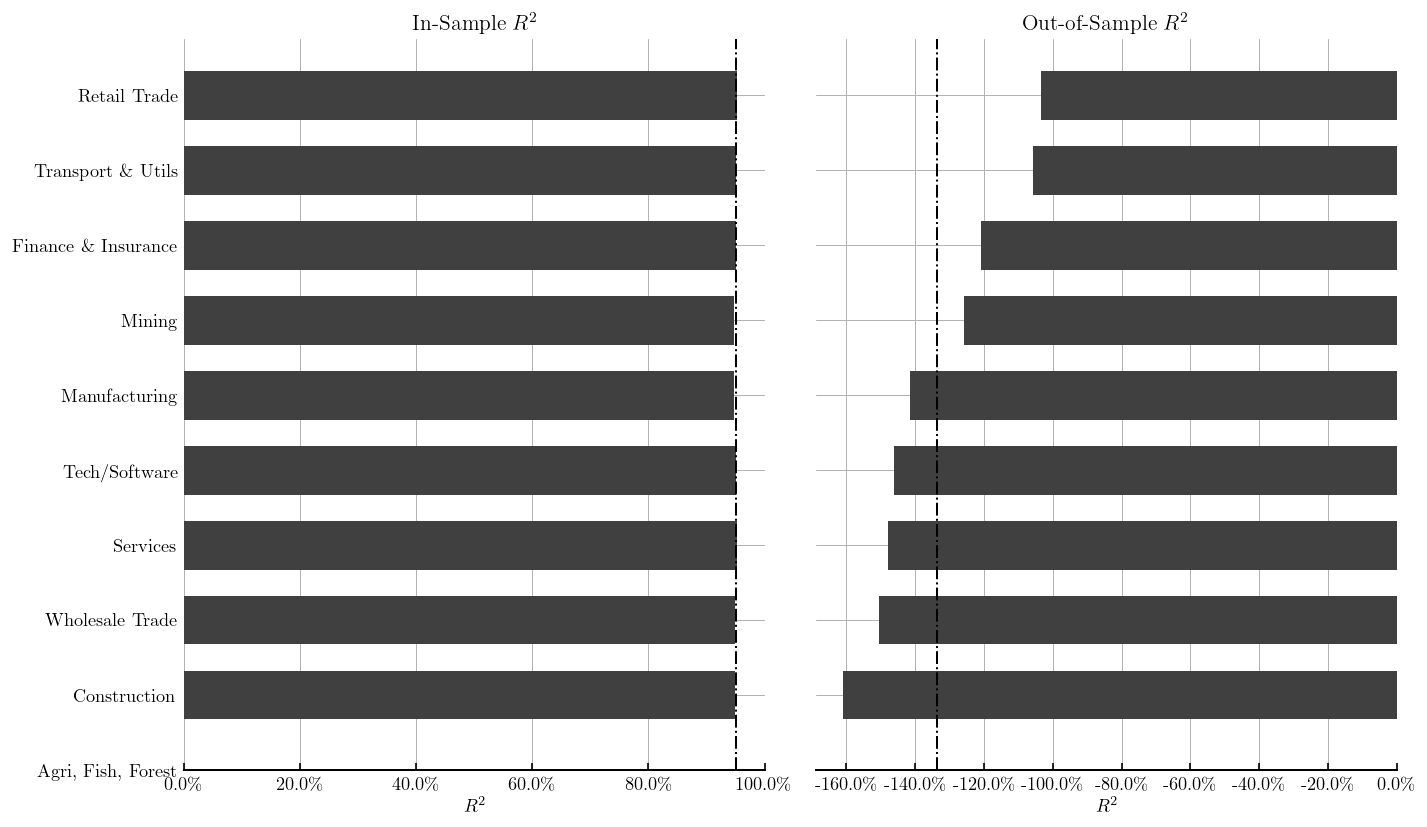

In [ ]:
# first plot shows mean insample fit of the lasso in each industry
# second plot shows mean industry wide oos fit of the lasso calculated usign the first oos prediction and the actual return
# closest match is fig 2 in chinco paper, although they consider the forecast improvement of the lasso in each industry, while
# we plot the first stage fit in each industry.
# 1. Prepare the industry mapping
# ---------------------------------------------------------
codes = pd.read_csv(r"C:\Users\jonat\Lasso_paper\codes.csv")

# Clean the mapping data before creating the dictionary
codes = codes.dropna(subset=['HSICCD']) 
codes['PERMNO'] = codes['PERMNO'].astype(str)

def sic_to_name(sic):
    if pd.isna(sic): return "Unknown"
    s = int(sic)
    if 100 <= s <= 999:    return "Agri, Fish, Forest"
    if 1000 <= s <= 1499:  return "Mining"
    if 1500 <= s <= 1799:  return "Construction"
    if 2000 <= s <= 3999:  return "Manufacturing"
    if 4000 <= s <= 4999:  return "Transport & Utils"
    if 5000 <= s <= 5199:  return "Wholesale Trade"
    if 5200 <= s <= 5999:  return "Retail Trade"
    if 6000 <= s <= 6799:  return "Finance & Insurance"
    if 7000 <= s <= 8999:  
        if 7370 <= s <= 7379: return "Tech/Software"
        return "Services"
    if 9000 <= s <= 9999:  return "Public Admin/Misc"
    return "Unknown"

codes['Industry'] = codes['HSICCD'].apply(sic_to_name)
industry_map = codes.set_index('PERMNO')['Industry'].to_dict()

# 2. Aggregate R2 Data by Industry
stock_mean_is_r2 = np.nanmean(r2_in_mat, axis=1)

stock_perf = pd.DataFrame({
    'PERMNO': stocks,
    'IS_R2': stock_mean_is_r2
})

stock_perf['Industry'] = stock_perf['PERMNO'].map(industry_map).fillna('Unknown')

# Calculate the global daily mean across ALL stocks, not just the industry
global_daily_mean = np.nanmean(targs_mat, axis=0) 

industry_results = []
for ind, group in stock_perf.groupby('Industry'):
    idx = group.index.values
    
    g_targs = targs_mat[idx, :]
    g_preds = preds_mat[idx, :]
    
    # Calculate SSE for the industry
    sse = np.nansum((g_targs - g_preds)**2)
    
    # Calculate SST using the GLOBAL daily mean
    sst = np.nansum((g_targs - global_daily_mean)**2)
    
    oos_r2 = 1 - (sse / sst) if sst != 0 else np.nan
    industry_results.append({'Industry': ind, 'IS_R2': group['IS_R2'].mean(), 'OOS_R2': oos_r2})

df_plot = pd.DataFrame(industry_results).set_index('Industry').sort_values('OOS_R2', ascending=False)
df_plot.index = [name.replace('&', r'\&') for name in df_plot.index]

# 3. Plotting (Chinco Fig 3)
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7), sharey=True, dpi=120)

y = np.arange(len(df_plot.index))
bar_height = 0.65
bar_color = '#404040' 

# Left Panel: In-Sample R2
ax1.barh(y, df_plot['IS_R2'], height=bar_height, color=bar_color)
mean_is = df_plot['IS_R2'].mean()
ax1.axvline(mean_is, color='black', linestyle='-.', linewidth=1.2)
ax1.set_title('In-Sample $R^2$', fontsize=13)
ax1.set_xlabel('$R^2$', fontsize=11)

# Right Panel: Out-of-Sample R2
ax2.barh(y, df_plot['OOS_R2'], height=bar_height, color=bar_color)
mean_oos = df_plot['OOS_R2'].mean()
ax2.axvline(mean_oos, color='black', linestyle='-.', linewidth=1.2)
ax2.set_title('Out-of-Sample $R^2$', fontsize=13)
ax2.set_xlabel('$R^2$', fontsize=11)

# Formatting
ax1.set_yticks(y)
ax1.set_yticklabels(df_plot.index)
ax1.invert_yaxis() 

pct_formatter = FuncFormatter(lambda x, pos: f"{x*100:.1f}\\%")

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    ax.tick_params(axis='y', left=False) 
    ax.tick_params(axis='x', direction='in', length=4, width=1)
    ax.xaxis.set_major_formatter(pct_formatter)

plt.tight_layout()
plt.show()

C:\Users\jonat\AppData\Local\Temp\ipykernel_57292\305273642.py:37: RuntimeWarning: Mean of empty slice
  stock_mean_is_s2_r2 = np.nanmean(s2_r2_in_mat, axis=1)
C:\Users\jonat\AppData\Local\Temp\ipykernel_57292\305273642.py:47: RuntimeWarning: Mean of empty slice
  global_daily_mean = np.nanmean(targs_mat, axis=0)


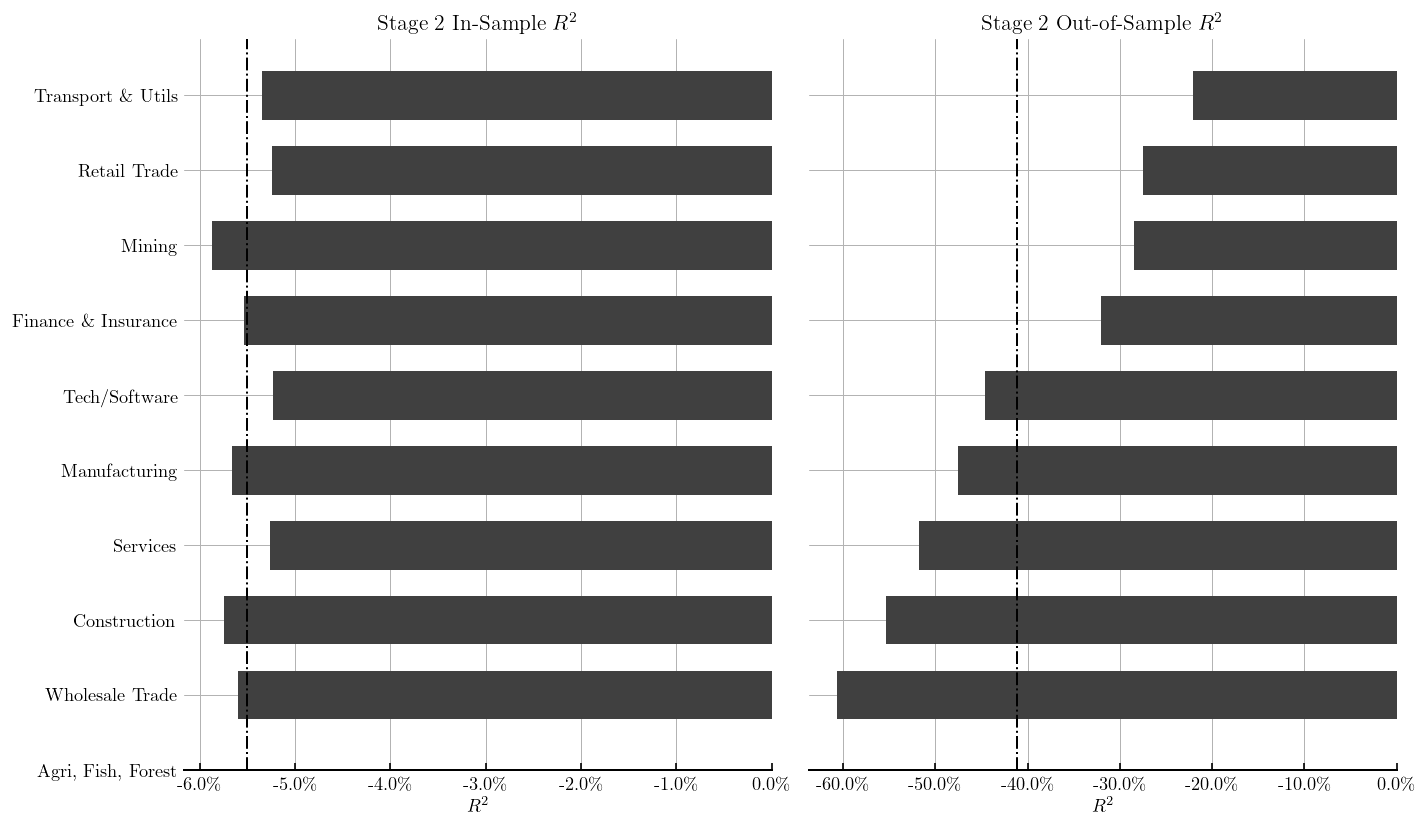

In [ ]:
# =============================================================================
# How R2 is computed per industry:
# 1. In-Sample R2 (IS_R2): Takes the time-average of the Stage 2 IS R2 for each 
#    individual stock, then averages these values across all stocks 
#    within the industry. R2 is calculated as the fit within each rolling window.
#
# 2. Out-of-Sample R2 (OOS_R2): Computes a pooled, aggregate R2. It sums the 
#    squared prediction errors (SSE) for all stocks in the industry over all days. 
#    It divides this by the total variance (SST), which is calculated relative 
#    to the *global market daily mean* (not the industry mean). This measures 
#    how much better the model predicts the industry's returns compared to just 
#    guessing the overall daily market average.
# =============================================================================

# 1. Prepare the industry mapping
# ---------------------------------------------------------
codes = pd.read_csv(r"C:\Users\jonat\Lasso_paper\codes.csv")

# Clean the mapping data before creating the dictionary
codes = codes.dropna(subset=['HSICCD']) 
codes['PERMNO'] = codes['PERMNO'].astype(str)

def sic_to_name(sic):
    if pd.isna(sic): return "Unknown"
    s = int(sic)
    if 100 <= s <= 999:    return "Agri, Fish, Forest"
    if 1000 <= s <= 1499:  return "Mining"
    if 1500 <= s <= 1799:  return "Construction"
    if 2000 <= s <= 3999:  return "Manufacturing"
    if 4000 <= s <= 4999:  return "Transport & Utils"
    if 5000 <= s <= 5199:  return "Wholesale Trade"
    if 5200 <= s <= 5999:  return "Retail Trade"
    if 6000 <= s <= 6799:  return "Finance & Insurance"
    if 7000 <= s <= 8999:  
        if 7370 <= s <= 7379: return "Tech/Software"
        return "Services"
    if 9000 <= s <= 9999:  return "Public Admin/Misc"
    return "Unknown"

codes['Industry'] = codes['HSICCD'].apply(sic_to_name)
industry_map = codes.set_index('PERMNO')['Industry'].to_dict()

# 2. Aggregate Stage 2 R2 Data by Industry
# ---------------------------------------------------------
# NOTE: Make sure `s2_r2_in_mat` is your Stage 2 In-Sample R2 matrix.
stock_mean_is_s2_r2 = np.nanmean(s2_r2_in_mat, axis=1)

stock_perf = pd.DataFrame({
    'PERMNO': stocks,
    'IS_R2': stock_mean_is_s2_r2
})

stock_perf['Industry'] = stock_perf['PERMNO'].map(industry_map).fillna('Unknown')

# Calculate the global daily mean across ALL stocks, not just the industry
global_daily_mean = np.nanmean(targs_mat, axis=0) 

industry_results = []
for ind, group in stock_perf.groupby('Industry'):
    idx = group.index.values
    
    g_targs = targs_mat[idx, :]
    
    # NOTE: Using Stage 2 predictions (s2_preds_mat) instead of Stage 1 (preds_mat)
    g_preds_s2 = s2_preds_mat[idx, :]
    
    # Calculate SSE for the industry using Stage 2 predictions
    sse = np.nansum((g_targs - g_preds_s2)**2)
    
    # Calculate SST using the GLOBAL daily mean
    sst = np.nansum((g_targs - global_daily_mean)**2)
    
    oos_r2 = 1 - (sse / sst) if sst != 0 else np.nan
    industry_results.append({'Industry': ind, 'IS_R2': group['IS_R2'].mean(), 'OOS_R2': oos_r2})

df_plot = pd.DataFrame(industry_results).set_index('Industry').sort_values('OOS_R2', ascending=False)
df_plot.index = [name.replace('&', r'\&') for name in df_plot.index]

# 3. Plotting
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7), sharey=True, dpi=120)

y = np.arange(len(df_plot.index))
bar_height = 0.65
bar_color = '#404040' 

# Left Panel: Stage 2 In-Sample R2
ax1.barh(y, df_plot['IS_R2'], height=bar_height, color=bar_color)
mean_is = df_plot['IS_R2'].mean()
ax1.axvline(mean_is, color='black', linestyle='-.', linewidth=1.2)
ax1.set_title('Stage 2 In-Sample $R^2$', fontsize=13)
ax1.set_xlabel('$R^2$', fontsize=11)

# Right Panel: Stage 2 Out-of-Sample R2
ax2.barh(y, df_plot['OOS_R2'], height=bar_height, color=bar_color)
mean_oos = df_plot['OOS_R2'].mean()
ax2.axvline(mean_oos, color='black', linestyle='-.', linewidth=1.2)
ax2.set_title('Stage 2 Out-of-Sample $R^2$', fontsize=13)
ax2.set_xlabel('$R^2$', fontsize=11)

# Formatting
ax1.set_yticks(y)
ax1.set_yticklabels(df_plot.index)
ax1.invert_yaxis() 

pct_formatter = FuncFormatter(lambda x, pos: f"{x*100:.1f}\\%")

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    ax.tick_params(axis='y', left=False) 
    ax.tick_params(axis='x', direction='in', length=4, width=1)
    ax.xaxis.set_major_formatter(pct_formatter)

plt.tight_layout()
plt.show()